# Проєкт "Аналіз оренди велосипедів"

У цьому проєкті працювала з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.

**Мета проєкту:** виконати аналіз даних за допомогою візуалізацій з використанням бібліотек pandas, matplotlib, дати відповіді на питання.

**Джерело даних:** https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv.

**Опис колонок:**
- `datetime` - дата та час
- `season` - сезон (1=весна, 2=літо, 3=осінь, 4=зима)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів


**Питання для проведення аналізу**
1. Яка динаміка оренди велосипедів?
2. Чи впливає чезон та температурний режим на кількість орендованих велосипедів?.
3. У який сезон пік оренди велосипедів?


## Підготовка даних

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантажую даних
df = pd.read_csv('data/yulu_rental.csv')

In [2]:
# Перетворюю datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [3]:
# Знайомство з даними
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


**Висновок:** даних 10886 рядків і 19 колонок. В кожному рядку містяться дані загальної кількості (сума) орендованих велосипедів за 1 годину.

## Поденна оренда велосипедів

In [4]:
# Групую кількість орендованих велосипедів поденно
daily_rent = df['count'].resample('D').sum()

In [5]:
daily_rent

datetime
2011-01-01     985
2011-01-02     801
2011-01-03    1349
2011-01-04    1562
2011-01-05    1600
              ... 
2012-12-15    5047
2012-12-16    3786
2012-12-17    4585
2012-12-18    5557
2012-12-19    5267
Freq: D, Name: count, Length: 719, dtype: int64

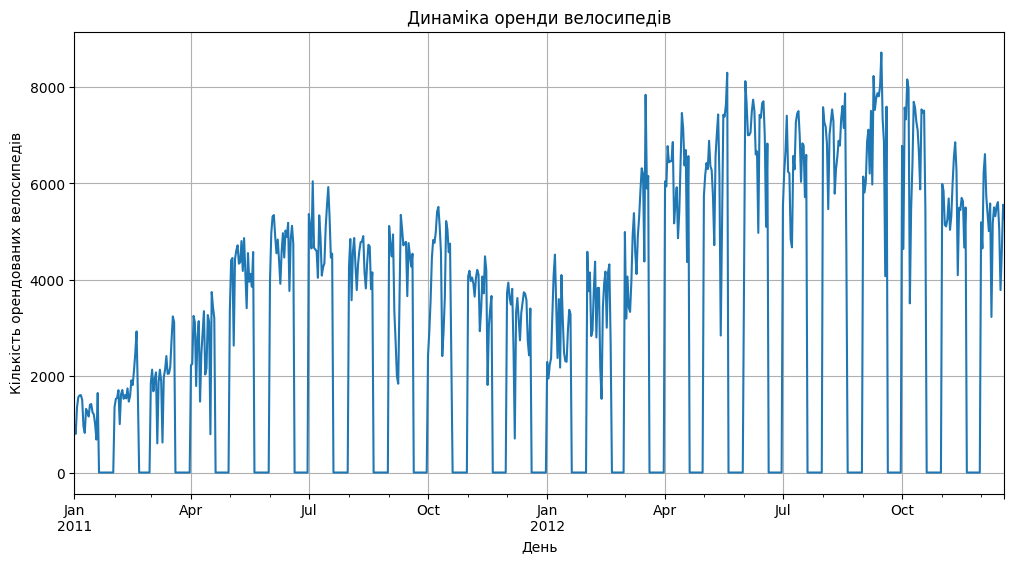

In [6]:
# Будую графік поденної кількості орендованих велосипедів за весь період в даних
daily_rent.plot(
    kind='line',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='День',
    ylabel='Кількість орендованих велосипедів',
    grid=True
);

**Висоновок:** на графіку видно "просадки", які повторюються з певною періодичністю. Можливо, це були робочі дні, тому кількість оренд тут падала до 0.

### Додаткові обчислення для з'ясування чи є дні з нульовою орендою робочими, чи вихідними?

In [7]:
# Обираю дні з нульовою орендою
daily_rent[daily_rent == 0]

datetime
2011-01-20    0
2011-01-21    0
2011-01-22    0
2011-01-23    0
2011-01-24    0
             ..
2012-11-26    0
2012-11-27    0
2012-11-28    0
2012-11-29    0
2012-11-30    0
Name: count, Length: 263, dtype: int64

In [8]:
# Агрегую з робочми днями (workingday)
daily_rent_df = df.resample('D').agg({
    'count': 'sum',
    'workingday': 'max'
}).reset_index()

# Дні з нульовою орендою
zero_rent_days = daily_rent_df[daily_rent_df['count'] == 0]

# Дивлюсь, які вони по workingday
print(zero_rent_days)
print(zero_rent_days['workingday'].value_counts(normalize=True))

      datetime  count  workingday
19  2011-01-20      0         NaN
20  2011-01-21      0         NaN
21  2011-01-22      0         NaN
22  2011-01-23      0         NaN
23  2011-01-24      0         NaN
..         ...    ...         ...
695 2012-11-26      0         NaN
696 2012-11-27      0         NaN
697 2012-11-28      0         NaN
698 2012-11-29      0         NaN
699 2012-11-30      0         NaN

[263 rows x 3 columns]
Series([], Name: proportion, dtype: float64)


**Висновок:**

На графіку помітні регулярні “просадки” — періоди, коли кількість оренд падала до нуля. Первинна гіпотеза полягала в тому, що це можуть бути робочі дні, проте додаткові обчислення показали, що для цих днів відсутні дані у стовпці workingday. Зокрема, для 263 днів із нульовою орендою немає інформації про те, чи були вони робочими чи вихідними.

Ймовірно, ми маємо справу не з реальними “просадками”, а з пропущеними даними. Щоб глибше дослідити це питання, у майбутньому варто детальніше опрацювати стовпець workingday та виявити причину відсутності значень. У межах цього проєкту заповнення цих пропусків не проводиться.

## Аналіз сезонності

In [9]:
# Створюю назви сезонів і обчислюю середню кількість оренд для кожного з них
season_mapping = {
    1: 'Весна',
    2: 'Літо',
    3: 'Осінь',
    4: 'Зима'
}
df['season_name'] = df['season'].map(season_mapping)
season_avg = df.groupby('season_name')['count'].mean().sort_values()
print(season_avg)

season_name
Весна    116.343261
Зима     198.988296
Літо     215.251372
Осінь    234.417124
Name: count, dtype: float64


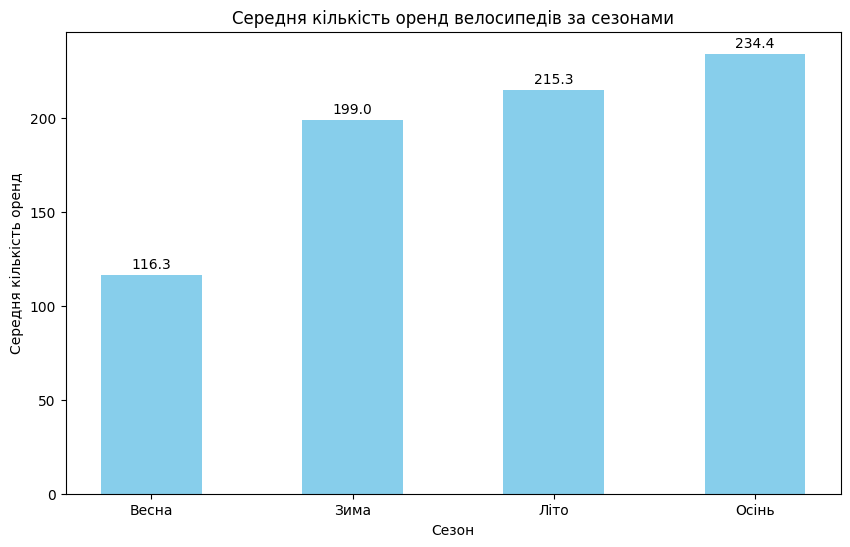

In [10]:
# Будую графік (Bar Plot) середньої кількості оренд велосипедів за сезонами
plt.figure(figsize=(10,6))
bars = plt.bar(
    season_avg.index,
    season_avg.values,
    color='skyblue',
    width=0.5)
plt.xlabel('Сезон')
plt.ylabel('Середня кількість оренд')
plt.title('Середня кількість оренд велосипедів за сезонами')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, round(yval, 1), 
             ha='center', va='bottom')
plt.show()

### Додаткові обчислення для з'ясування, в який сезон найбільша середня кількість оренди велосипедів

In [11]:
a = season_avg.max()  # максимальне середнє значення
b = season_avg.min()  # мінімальне середнє значення
ratio = a / b        # відношення
print(f"Максимальне значення (a): {a:.2f}")
print(f"Мінімальне значення (b): {b:.2f}")
print(f"Відношення a/b: {ratio:.2f}")

Максимальне значення (a): 234.42
Мінімальне значення (b): 116.34
Відношення a/b: 2.01


**Висновок:**

 Найбільша середня кількість оренди велосипедів восени - 234,42 оренди в середньому.
 Сезонна закономірність пояснюється тим, що восени сприятлива погода, активний сезон для навчаня та роботи.
 
 Оренда між найпопулярнішим та найменш популярним сезоном відрізняється у 2,01 раз, тобто оренда восени вдвічі більша, ніж оренда навесні.

## Динаміка за місяцями

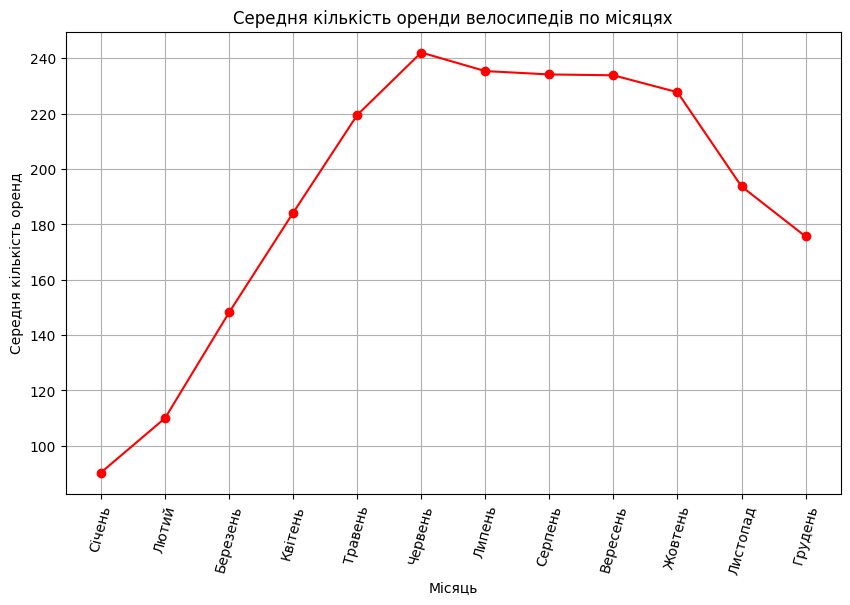

In [12]:
# Графік (Line Plot) середньої кількості оренди велосипедів по місяцях
monthly_avg = df.groupby('month')['count'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(
    monthly_avg['month'],
    monthly_avg['count'],
    marker='o',
    color='red'
)
plt.title('Середня кількість оренди велосипедів по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд')
ukr_months = [
    'Січень', 'Лютий', 'Березень', 'Квітень',
    'Травень', 'Червень', 'Липень', 'Серпень',
    'Вересень', 'Жовтень', 'Листопад', 'Грудень'
]
plt.xticks(range(1, 13), ukr_months, rotation = 75)
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

**Висновок:**

З червня по вересень включно (06-09 місяці) спостерігається пік оренди велосипедів. З жовтня (10 місяць) відбувається спад оренди. Ця закономірність збігається з результатами попередньго аналізу (сезонності): маємо вищі значення влітку і менші взимку — лінійний тренд підтвердив сезонність.

Клімат має безпосередній вплив на оренду велосипедів протягом року: чим тепліше і сухіше, тим більше людей обирають велосипед.

## Розподіл погодних умов

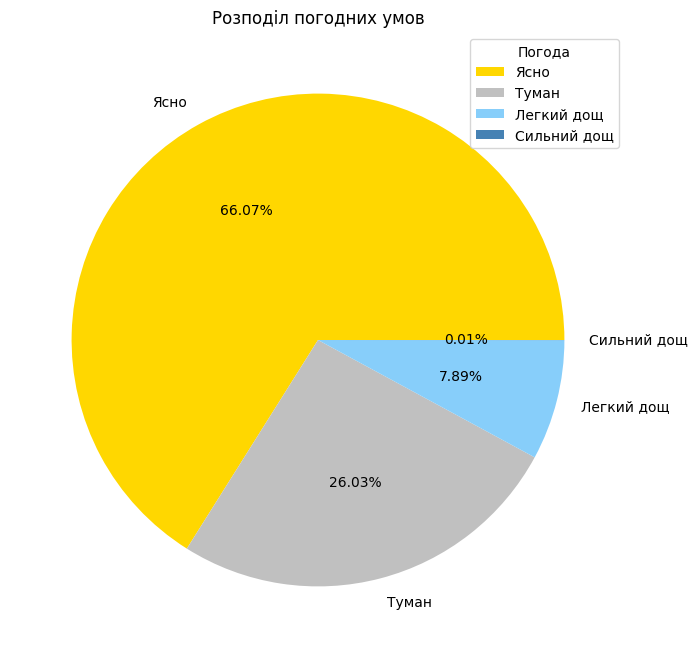

In [14]:
# Візуалізація розподілу погодних умов у вигляді кругової діаграми
# Кожен сектор показує частку випадків певного типу погоди (ясно, туман, легкий чи сильний дощ)
weather_counts = df['weather'].value_counts().sort_index()
labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
colors = ['#FFD700', '#C0C0C0', '#87CEFA', '#4682B4']
plt.figure(figsize=(8,8))
plt.pie(
    weather_counts,
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=0
)
plt.title('Розподіл погодних умов')
plt.legend(labels, title="Погода", loc="best")
plt.show()

**Висновок:**

В датасеті переважає ясна погода (66,07 %).

Дні із сильним дощем є, але їх частка дуже незначна - 0,01 %.

Погодні умови безпосередньо впливають на попит на оренду велосипедів: чим гірші погодні умови (дощ, туман), тим менше людей беруть в оренду велосипеди.

## Аналіз викидів

In [15]:
# Підготовка даних для побудови box plot за типами погоди  
# Створюю нову колонку з назвами погодних умов, задаю порядок категорій  
# Групую дані за погодою для подальшого аналізу розподілу кількості оренд (включаючи можливі викиди)
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}
ordered_labels = list(weather_labels.values())
df['weather_label'] = df['weather'].map(weather_labels)
df['weather_label'] = pd.Categorical(df['weather_label'], categories=ordered_labels, ordered=True)
grouped_data = df.groupby('weather_label', observed=True)['count'].apply(list)

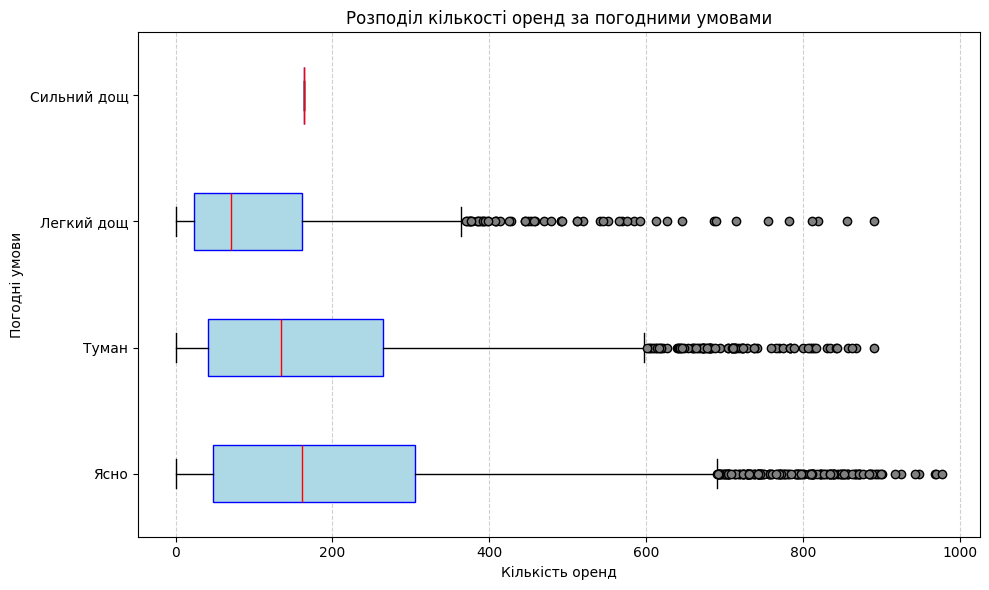

In [16]:
# Побудова графіка
plt.figure(figsize=(10, 6))
plt.boxplot(
    grouped_data,
    vert=False, 
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='blue'),
    medianprops=dict(color='red'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=6)
)
plt.yticks(ticks=range(1, len(grouped_data) + 1), labels=grouped_data.index)
plt.title('Розподіл кількості оренд за погодними умовами')
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Висновок:**

При ясній погоді спостерігається найбільший розкид у кількості оренди, що свідчить про значну варіативність попиту у ці дні.

Є викиди (outliers) при всіх типах погоди, окрім сильного дощу. Найбільше викидів при ясній погоді.

Найвище медіанне значення оренди спостерігається при ясній погоді, тобто саме в ці дні попит на велосипеди в середньому найвищий.

Отже, попит на оренду велосипедів залежить від погодних умов — найсприятливіші умови сприяють більшій активності користувачів.

## Кореляція температури та оренди (Scatter Plot)

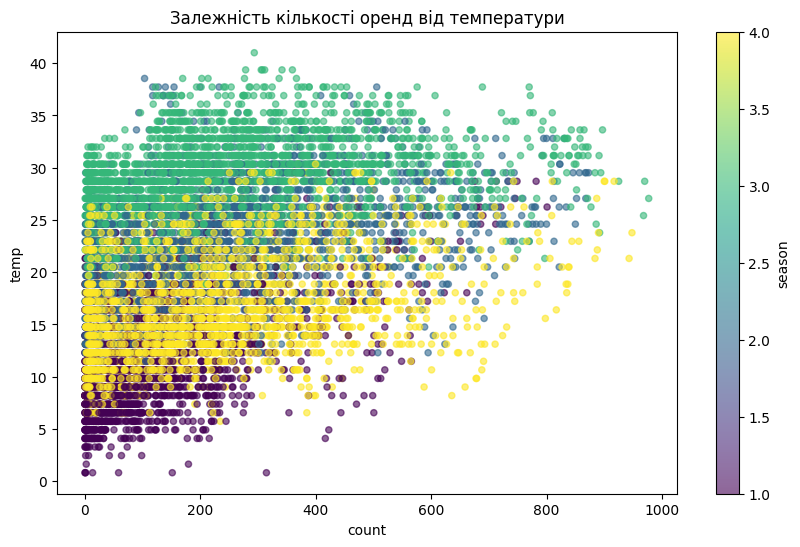

In [17]:
# Побудова графіка (Scatter Plot) для розуміння залежності кількості оренд від температури
df.plot.scatter(
    x='count',
    y='temp',
    c='season',
    colormap='viridis',
    title='Залежність кількості оренд від температури',
    figsize=(10, 6),
    alpha=0.6,
    colorbar=True
)
plt.show()

**Висновок:**

Між температурою та кількістю оренди є прямий зв'язок: чим вища температура, тим, більша кількість оренди велосипедів.

На діаграмі розсіювання видно згущення точок у верхній частині при вищій температурі.

Колірна шкала сезонів також підтверджує, що весна–літо пов’язані з більшою кількістю оренд.

## Порівняння користувачів

In [18]:
# Підготовка даних для побудови графіка з накопиченням (Stacked Bar Chart)
avg_by_weekday = df.groupby('weekday_num')[['casual', 'registered']].mean()
weekday_labels = ['Понеділок', 'Вівторок', 'Середа', 'Четвер', 'Пʼятниця', 'Субота', 'Неділя']
avg_by_weekday = avg_by_weekday.reindex([0,1,2,3,4,5,6])

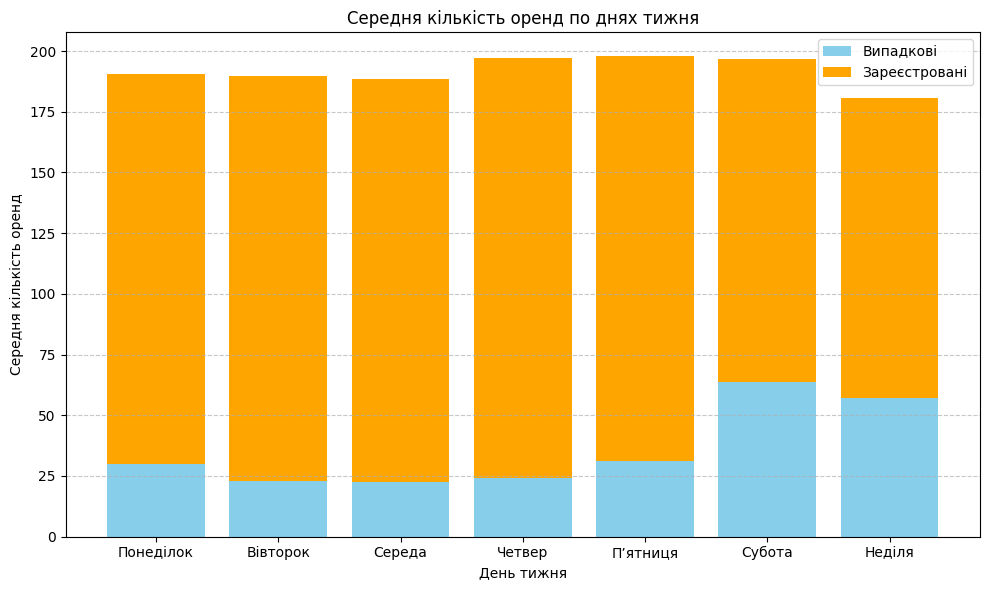

In [19]:
# Будую графік, щоб дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.
plt.figure(figsize=(10,6))
plt.bar(weekday_labels, avg_by_weekday['casual'], label='Випадкові', color='skyblue')
plt.bar(weekday_labels, avg_by_weekday['registered'], 
        bottom=avg_by_weekday['casual'], label='Зареєстровані', color='orange')
plt.title('Середня кількість оренд по днях тижня')
plt.xlabel('День тижня')
plt.ylabel('Середня кількість оренд')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Висновок:**

Четвер, п’ятниця та субота — дні, коли зареєстровані користувачі найактивніше беруть велосипеди в оренду.

Четвер і п’ятниця - це кінець робочого тижня, коли люди можуть активніше пересуватися містом на велосипеді — не лише на роботу, а й по особистих справах або на зустрічі. Також у п’ятницю може зростати кількість поїздок у вільний час, після завершення робочого дня.

Використання у суботу може свідчити про те, що частина зареєстрованих користувачів використовує велосипед і у вихідні — для активного відпочинку, поїздок на дачу, прогулянок тощо. Також це може бути мобільно активна молодь або постійні користувачі, які віддають перевагу велосипеду у вихідний.
Випадкові (casual) користувачі можуть бути активні лише у вихідні, а зареєстровані — у п’ятницю та суботу, коли в них більше вільного часу, але є звичка до використання велосипеда.

Отже, зареєстровані користувачі активно використовують велосипеди не тільки у будні, а й у період “перед вихідними”, що свідчить про гнучке використання транспорту в місті, сталі звички або навіть зміщення трудової активності на кінець тижня.

## Загальний висновок, відповіді на питання, поставлені на початку проведення аналізу

**Загальний висновок:** У датасеті міститься 10 886 записів із погодинною кількістю оренд велосипедів (19 ознак). Попередній огляд показав наявність регулярних “просадок” у даних — днів, коли кількість оренд дорівнює нулю. Подальша перевірка виявила, що для більшості з них відсутня інформація про робочі дні, тому ці “просадки” найімовірніше пояснюються пропущеними значеннями, а не реальною відсутністю оренд.

***1. Динаміка оренди велосипедів.*** Попит на оренду має виражену сезонну динаміку: із червня по вересень кількість оренд стабільно найвища, після чого відбувається поступовий спад. Високі показники зберігаються у четвер–суботу, що свідчить про активне використання велосипедів наприкінці робочого тижня та у вихідні.

***2. Вплив сезону та температури.*** Аналіз показав прямий зв’язок між температурою та кількістю оренд — зі зростанням температури кількість оренд також підвищується. Крім того, ясна та суха погода сприяє більшій активності користувачів, тоді як дощ чи туман суттєво знижують попит.

***3. Сезон пікових оренд.*** Найбільша середня кількість оренд зафіксована восени (234,4 оренди/год), що приблизно у 2 рази більше, ніж навесні. Цей період вирізняється комфортною погодою, активним навчальним та робочим сезоном, тому попит на велосипеди є найвищим.

**Отже, оренда велосипедів має чітко виражену сезонність і залежність від погоди: найвищі показники спостерігаються у теплі та ясні місяці, особливо восени. Зареєстровані користувачі активно користуються велосипедами не лише у будні, а й у вихідні, що вказує на сталу мобільну культуру та інтеграцію велосипедів у повсякденне життя міста.**